SWC Lab meeting plots:
- diff in prediction accuracy bars, sessions and mouse averages [done]
- diff in prediction accuracy first and second half [done]
- diff in prediction accuracy first and second half but for the first session [done]

Supplementary:
- pred.acc. diff over time [done]
- pred acc. diff top to bottom of arena [done]
- compare to homings
- is the pa of postflip increasing or preflip decreasing?

In [123]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may]

barrier_sesh_by_mouse = {'JAL003': ['2023_08_22','2023_08_25','2023_08_29','2023_09_01','2023_09_04','2023_09_07'],
                         'JAL004': ['2023_08_21','2023_08_24','2023_08_28','2023_09_03','2023_09_11','2023_09_19'],
                         'JAL005': ['2023_09_05','2023_09_08','2023_09_14','2023_09_21','2023_09_26','2023_09_28'],
                         'JAL006': ['2024_03_11','2024_03_14','2024_03_18','2024_03_21','2024_03_25','2024_03_28','2024_04_01','2024_04_05'],
                         'JAL007': ['2024_03_12','2024_03_15','2024_03_19','2024_03_22','2024_03_26','2024_04_04','2024_04_09','2024_04_16','2024_04_23'],
                         'JAL008': ['2024_04_25','2024_04_29','2024_05_7','2024_05_10','2024_05_14']}

In [124]:
from behave_analysis.process.session import get_experiment 
from JR_test_scripts.tracking2features import extract_pa_across_sesh

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [133]:
# fixed vars
ceph_path = r"Z:\Jasmine_Laurence\Experimental_Data"
winstor_path = r"Y:\Laurence"
# save_path = r"Z:\Jasmine_Laurence\SWClabmeeting\running_only"
save_path = r"Z:\Jasmine_Laurence\SWClabmeeting\excl_prox"
conditions = ['shelter_only','barrier_pre_flip','barrier_post_flip']
all_angles = ['hdir','hsa','h_preflipbar_a','h_postflipbar_a','h_rightbar_a','h_leftbar_a']
all_features = ['shelter','preflip_barrier','postflip_barrier','left_barrier', 'right_barrier', 'arena_bottom', 'arena_top']
settings = 'all_angles_fr_excl_prox_15cm'
# 'all_angles_fr','all_angles_fr_excl_prox_15cm','all_angles_subsampled_fr','all_angles_subsampled_fr_excl_prox_15cm', 'all_angles_fr_excl_stationary'

In [134]:
# pulling out prediction accuracy for all sessions for a certain set of settings

sessy, all_names, avg_pa, pa = extract_pa_across_sesh(all_angles,experiments_objects, conditions, all_features, settings)

Preflip vs Postflip

In [135]:
"""Mouse averages"""
mouse_ID = [x[:6] for x in all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
m_pa = {}
for key in pa.keys():
    if key not in m_pa:
        m_pa[key] = np.zeros((len(unique_mouse),3))
for idx, a in enumerate(all_angles):
    for m_idx, m in enumerate(unique_mouse):
        this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
        m_pa[a][m_idx,:] = np.mean(pa[a][this_mouse,:], axis=0)

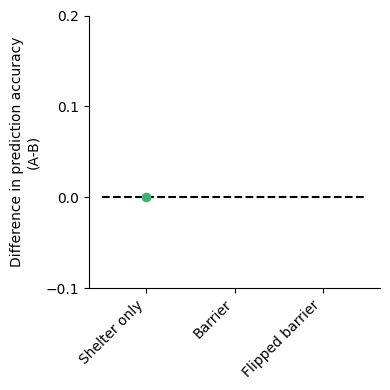

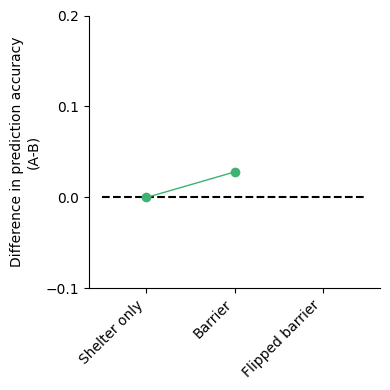

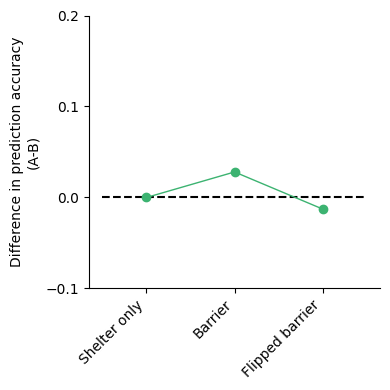

In [53]:
''' Plot the difference in pa for two goals'''
c = ['h_preflipbar_a','h_postflipbar_a']
cond = ['Shelter only','Barrier','Flipped barrier']
# good = [0, 7, 9, 14, 19,22,25]
diff = pa[c[0]] - pa[c[1]]
idx = 0
p = diff[idx,:]

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.plot([-.5,2.5],[0,0],'--k')
axs.plot(conditions[:1],p[:1],color = 'mediumseagreen',alpha = 1, linewidth = 1, marker = 'o')
axs.set_xticks(np.arange(len(conditions)))
axs.set_yticks([-.1,0,.1,.2])
axs.set_xticklabels(cond,rotation = 45, ha="right")
axs.set_ylim([-.1,.2])
axs.set_ylabel('Difference in prediction accuracy\n(A-B)')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff1_'+all_names[idx]+'_'+settings+'.png'))

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.plot([-.5,2.5],[0,0],'--k')
axs.plot(conditions[:2],p[:2],color = 'mediumseagreen',alpha = 1, linewidth = 1, marker = 'o')
axs.set_xticks(np.arange(len(conditions)))
axs.set_yticks([-.1,0,.1,.2])
axs.set_xticklabels(cond,rotation = 45, ha="right")
axs.set_ylim([-.1,.2])
axs.set_ylabel('Difference in prediction accuracy\n(A-B)')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff2_'+all_names[idx]+'_'+settings+'.png'))

fig, axs = plt.subplots(1,1,figsize = (4,4))
axs.plot([-.5,2.5],[0,0],'--k')
axs.plot(conditions,p,color = 'mediumseagreen',alpha = 1, linewidth = 1, marker = 'o')
axs.set_xticks(np.arange(len(conditions)))
axs.set_yticks([-.1,0,.1,.2])
axs.set_xticklabels(cond,rotation = 45, ha="right")
axs.set_ylim([-.1,.2])
axs.set_ylabel('Difference in prediction accuracy\n(A-B)')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff3_'+all_names[idx]+'_'+settings+'.png'))


In 17 of 25 sessions A is better decoded than B in shelter only condition
In 21 of 25 sessions open side is better decoded than closed side in pre flip condition
In 16 of 25 sessions open side is better decoded than closed side in post flip condition


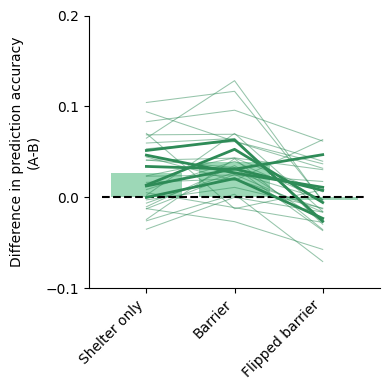

In [146]:
''' Plot the difference in pa for two goals'''
c = ['h_preflipbar_a','h_postflipbar_a']
cond = ['Shelter only','Barrier','Flipped barrier']

fig, axs = plt.subplots(1,1,figsize = (4,4))

diff = pa[c[0]] - pa[c[1]]
axs.bar(conditions,np.nanmean(diff,axis=0),color = 'mediumseagreen',alpha = .5)
for p in diff:
    axs.plot(conditions,p,color = 'seagreen',alpha = .5, linewidth = .75)
axs.plot([-.5,2.5],[0,0],'--k')
diff = m_pa[c[0]] - m_pa[c[1]]
for m, p in enumerate(diff):
    axs.plot(conditions, p, linewidth = 2, label = unique_mouse[m], color = 'seagreen')
axs.set_xticks(np.arange(len(conditions)))
axs.set_xticklabels(cond,rotation = 45, ha="right")
axs.set_yticks([-.1,0,.1,.2])
axs.set_ylim([-.1,.2])
axs.set_ylabel('Difference in prediction accuracy\n(A-B)')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff_allsesh_'+settings+'.png'))

diff = pa[c[0]] - pa[c[1]]
print('In ' + str(np.sum(diff[:,0] > 0)) + ' of ' + str(len(diff[:,0])) + ' sessions A is better decoded than B in shelter only condition')
print('In ' + str(np.sum(diff[:,1] > 0)) + ' of ' + str(len(diff[:,1])) + ' sessions open side is better decoded than closed side in pre flip condition')
print('In ' + str(np.sum(diff[:,2] < 0)) + ' of ' + str(len(diff[:,2])) + ' sessions open side is better decoded than closed side in post flip condition')

Top vs bottom

In [137]:
"""Mouse averages"""
mouse_ID = [x[:6] for x in all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
m_avg_pa = {}
for key in avg_pa.keys():
    if key not in m_pa:
        m_avg_pa[key] = np.zeros((len(unique_mouse),3))
for idx, a in enumerate(avg_pa.keys()):
    for m_idx, m in enumerate(unique_mouse):
        this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
        m_avg_pa[a][m_idx,:] = np.mean(avg_pa[a][this_mouse,:], axis=0)

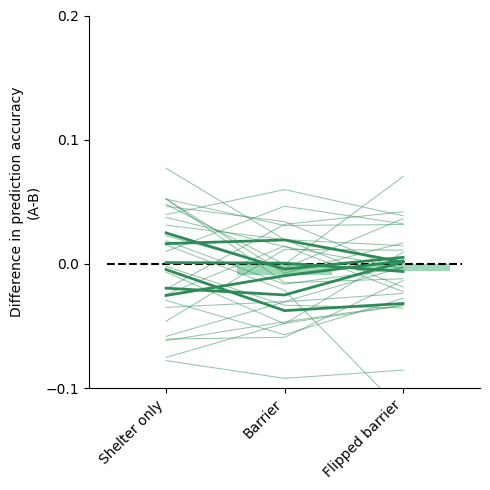

In [138]:
''' Plot the difference in pa for two goals'''
c = ['arena_bottom', 'arena_top']
cond = ['Shelter only','Barrier','Flipped barrier']

fig, axs = plt.subplots(1,1,figsize = (5,5))

diff = avg_pa[c[0]] - avg_pa[c[1]]
axs.bar(conditions,np.nanmean(diff,axis=0),color = 'mediumseagreen',alpha = .5)
for p in diff:
    axs.plot(conditions,p,color = 'seagreen',alpha = .5, linewidth = .75)
axs.plot([-.5,2.5],[0,0],'--k')
diff = m_avg_pa[c[0]] - m_avg_pa[c[1]]
for m, p in enumerate(diff):
    axs.plot(conditions, p, linewidth = 2, label = unique_mouse[m], color = 'seagreen')
axs.set_xticks(np.arange(len(conditions)))
axs.set_xticklabels(cond,rotation = 45, ha="right")
axs.set_yticks([-.1,0,.1,.2])
axs.set_ylim([-.1,.2])
axs.set_ylabel('Difference in prediction accuracy\n(A-B)')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_bttom_top_diff_allsesh_'+settings+'.png'))

diff = avg_pa[c[0]] - avg_pa[c[1]]
for i in [0,1,2]:
    print('In ' + str(np.sum(diff[:,i] > 0)) + ' of ' + str(len(diff[:,i])) + ' sessions bottom is better decoded than top in ' + cond[i] + ' condition')

Right vs left

In 18 of 25 sessions left is better decoded than right in Shelter only condition
In 17 of 25 sessions left is better decoded than right in Barrier condition
In 17 of 25 sessions left is better decoded than right in Flipped barrier condition


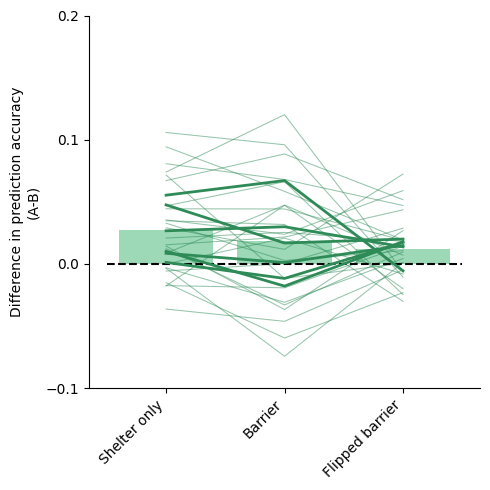

In [147]:
''' Plot the difference in pa for two goals'''
c = ['left_barrier', 'right_barrier']
cond = ['Shelter only','Barrier','Flipped barrier']

fig, axs = plt.subplots(1,1,figsize = (5,5))

diff = avg_pa[c[0]] - avg_pa[c[1]]
axs.bar(conditions,np.nanmean(diff,axis=0),color = 'mediumseagreen',alpha = .5)
for p in diff:
    axs.plot(conditions,p,color = 'seagreen',alpha = .5, linewidth = .75)
axs.plot([-.5,2.5],[0,0],'--k')
diff = m_avg_pa[c[0]] - m_avg_pa[c[1]]
for m, p in enumerate(diff):
    axs.plot(conditions, p, linewidth = 2, label = unique_mouse[m], color = 'seagreen')
axs.set_xticks(np.arange(len(conditions)))
axs.set_xticklabels(cond,rotation = 45, ha="right")
axs.set_yticks([-.1,0,.1,.2])
axs.set_ylim([-.1,.2])
axs.set_ylabel('Difference in prediction accuracy\n(A-B)')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig(save_path+'/'+str('pa_left_right_diff_allsesh_'+settings+'.png'))

diff = avg_pa[c[0]] - avg_pa[c[1]]
for i in [0,1,2]:
    print('In ' + str(np.sum(diff[:,i] > 0)) + ' of ' + str(len(diff[:,i])) + ' sessions left is better decoded than right in ' + cond[i] + ' condition')

In [153]:
np.shape(diff)

(2, 25)

In 19 of 25 sessions left is better decoded than right in Shelter only condition


IndexError: list index out of range

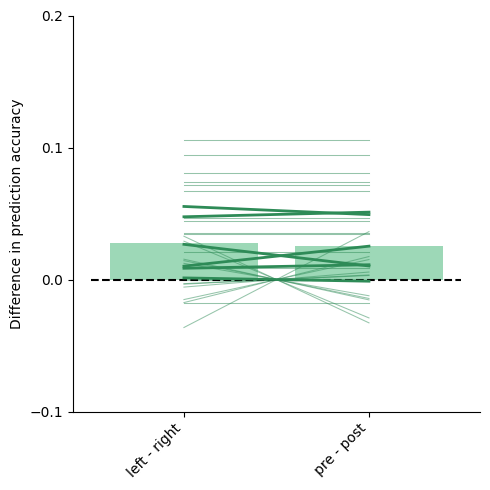

In [157]:
''' Plot the difference in pa for two goals'''
c = ['preflip_barrier','postflip_barrier']
avg_c = ['left_barrier', 'right_barrier']
cond = ['Shelter only']
x_ax = ['left - right','pre - post']

fig, axs = plt.subplots(1,1,figsize = (5,5))

diff = np.vstack((avg_pa[avg_c[0]][:,0] - avg_pa[avg_c[1]][:,0],
           avg_pa[c[0]][:,0] - avg_pa[c[1]][:,0])).T
axs.bar(x_ax,np.nanmean(diff,axis=0),color = 'mediumseagreen',alpha = .5)
for p in diff:
    axs.plot(x_ax,p,color = 'seagreen',alpha = .5, linewidth = .75)
axs.plot([-.5,1.5],[0,0],'--k')
diff = np.vstack((m_avg_pa[avg_c[0]][:,0] - m_avg_pa[avg_c[1]][:,0],
           m_avg_pa[c[0]][:,0] - m_avg_pa[c[1]][:,0])).T
for m, p in enumerate(diff):
    axs.plot(x_ax, p, linewidth = 2, label = unique_mouse[m], color = 'seagreen')
axs.set_xticks(np.arange(len(x_ax)))
axs.set_xticklabels(x_ax,rotation = 45, ha="right")
axs.set_yticks([-.1,0,.1,.2])
axs.set_ylim([-.1,.2])
axs.set_ylabel('Difference in prediction accuracy')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig(save_path+'/'+str('pa_left_right_diff_allsesh_'+settings+'.png'))

Across sessions

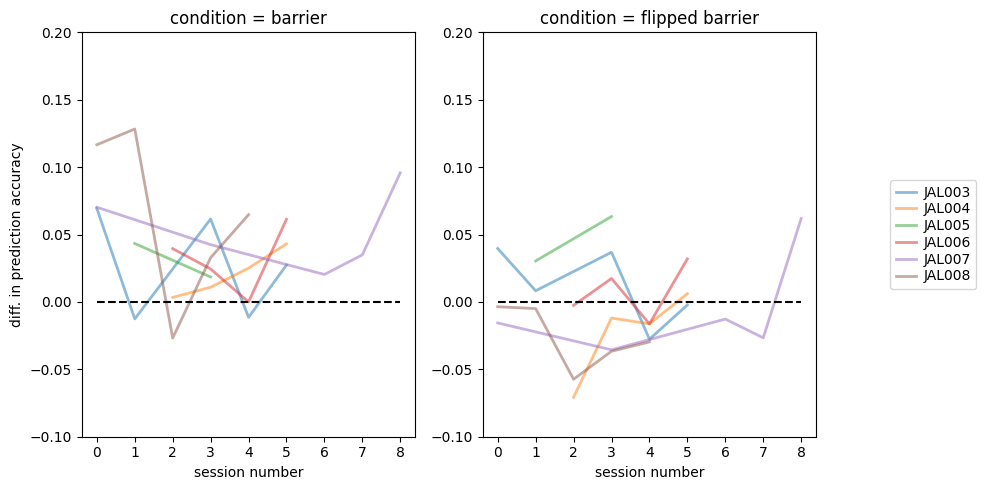

In [139]:
'''Find for each mouse the sessions in order and plot the prediction accuracy,
labeled by which barrier sessions this is'''
mouse = ['JAL003','JAL004','JAL005','JAL006','JAL007','JAL008']
diff = pa['h_preflipbar_a'] - pa['h_postflipbar_a']

fig, axs = plt.subplots(1,2, figsize = (10,5))

for m in mouse:
    this_m = [c for c in all_names if m in c]
    this_m_idx = []
    for sesh in this_m:
        this_m_idx.append([i for i,m in enumerate(barrier_sesh_by_mouse[m]) if m in sesh][0])
    this_m_idx = np.array(this_m_idx)
    sort_idx = np.argsort(this_m_idx)
    this_m_val = np.array([d for c,d in zip(all_names,diff[:,1]) if m in c]) # preflip
    axs[0].plot(this_m_idx[sort_idx],this_m_val[sort_idx], linewidth = 2, alpha = .5)
    this_m_val = np.array([d for c,d in zip(all_names,diff[:,2]) if m in c]) # postflip
    axs[1].plot(this_m_idx[sort_idx],this_m_val[sort_idx], linewidth = 2, alpha = .5)

axs[0].set_ylabel('diff. in prediction accuracy')
axs[0].set_title('condition = barrier')
axs[1].set_title('condition = flipped barrier')
axs[1].legend(mouse,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)
for i in [0,1]: 
    axs[i].plot([0,8],[0,0],'--k')
    axs[i].set_xlabel('session number')
    axs[i].set_xticks(np.arange(0,9,1))
    axs[i].set_ylim([-.1,.2])

plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_diff_allsesh_'+settings+'_overtime.png'))

First half vs second half

In [132]:
time_cond = ["first_half", "second_half"]
sessy, all_names, avg_pa, pa = extract_pa_across_sesh(
    all_angles, experiments_objects, conditions, all_features, settings, bar_angles=False, time_cond=time_cond
)

skipping condition! Path still doesn't exist: Z:\Jasmine_Laurence\Experimental_Data\JAL003\003_003puftrotato3_2023_09_07T12_23_47\processed_data\models\LDA\all_angles_fr_excl_stationary\good\first_half\all\shelter_only\good_shelter_only_LDA_pa.pkl


AttributeError: 'list' object has no attribute 'keys'

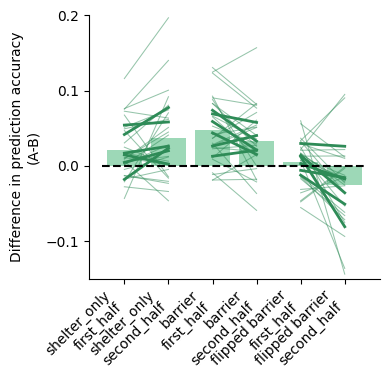

In [93]:
'''Plot diff in prediction accuracy in first vs second half averaged by mouse'''
fig, axs = plt.subplots(1,1, figsize = (4,4))
angle = ['h_preflipbar_a','h_postflipbar_a']
cond = ['shelter_only','barrier','flipped barrier']
aligned = []
name = []
for c_idx, c in enumerate(conditions):
    for t_idx, t in enumerate(time_cond):
        if len(aligned) == 0:
            aligned = pa[angle[0]][:,c_idx,t_idx] - pa[angle[1]][:,c_idx,t_idx]
        else:
            aligned = np.vstack((aligned, pa[angle[0]][:,c_idx,t_idx] - pa[angle[1]][:,c_idx,t_idx]))
        name.append(str(cond[c_idx] + '\n' + t))

# aligned = np.delete(aligned,15,1)
# not_all_names = all_names[:15] + all_names[16:]
not_all_names = all_names

mouse_ID = [x[:6] for x in not_all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
mean_aligned = np.zeros((len(unique_mouse),np.shape(aligned)[0]))
for m_idx, m in enumerate(unique_mouse):
    this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
    mean_aligned[m_idx,:] = np.mean(aligned[:,this_mouse], axis=1)

for i in [0,2,4]:
    axs.bar(name[i:i+2],np.nanmean(aligned[i:i+2,:],axis=1),color = 'mediumseagreen',alpha = .5)
    axs.plot(name[i:i+2],aligned[i:i+2,:],color = 'seagreen',alpha = .5, linewidth = .75)
    axs.plot(name[i:i+2],mean_aligned[:,i:i+2].T, linewidth = 2, color = 'seagreen')
axs.plot([-.5,np.shape(aligned)[0]-.5],[0,0],'--k')
axs.set_xticks(np.arange(np.shape(aligned)[0]))
axs.set_xticklabels(name,rotation = 45, ha="right")
axs.set_yticks([-.1,0,.1,.2])
axs.set_ylim([-.15,.2])
axs.set_ylabel('Difference in prediction accuracy\n(A-B)')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig(save_path+'/'+str('diff_pa_first_second_half_all_avg.png'))

In [113]:
"""Stats on the difference between first vs second half per condition
t-test"""
import scipy.stats as stats
for i in [0,2,4]:
    d1 = aligned[i,:]
    d2 = aligned[i+1,:]
    print('d1 var: ' + str(np.var(d1)) + ' , d2 var: ' + str(np.var(d2)))
    print('var ratio: ' + str(np.var(d2)/np.var(d1)))
    # st, p, df = 
    print(stats.ttest_ind(a = d1, b = d2, alternative = 'two-sided'))

d1 var: 0.0014683108071395286 , d2 var: 0.003213803096821982
var ratio: 2.188775755919765
TtestResult(statistic=np.float64(-1.1053441419478018), pvalue=np.float64(0.2745202110040275), df=np.float64(48.0))
d1 var: 0.0019294938416231158 , d2 var: 0.0021147387765865213
var ratio: 1.0960070102154744
TtestResult(statistic=np.float64(1.209522695739201), pvalue=np.float64(0.23238571367809083), df=np.float64(48.0))
d1 var: 0.0009430852084103325 , d2 var: 0.003032180628625157
var ratio: 3.2151714411216465
TtestResult(statistic=np.float64(2.434714684509116), pvalue=np.float64(0.01867127154714993), df=np.float64(48.0))


In [112]:
"""Stats on the difference between first vs second half per condition
permutation"""
for i in [0,2,4]:
    d1 = aligned[i,:]
    d2 = aligned[i+1,:]
    real_stat = np.abs(np.mean(d1)-np.mean(d2))
    print('real stat: ' + str(real_stat))
    d = np.hstack((d1,d2))
    shuffled = np.zeros(1000)
    for j in np.arange(1000):
        idx = np.random.uniform(low = 0,high = 1, size =len(d))
        d_sort = d[np.argsort(idx)]
        shuffled[j] = np.abs(np.mean(d_sort[:len(d1)]) - np.mean(d_sort[len(d1):]))
    print(np.sum(shuffled > real_stat)/1000)

real stat: 0.015438776510219052
0.283
real stat: 0.015700969317716765
0.231
real stat: 0.03133470009977266
0.019


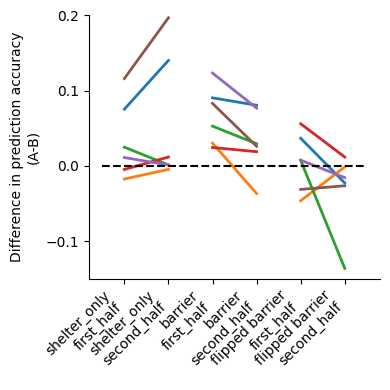

In [32]:
first_sesh_by_mouse = ['JAL003_2023_08_22','JAL004_2023_08_28','JAL005_2023_09_08','JAL006_2024_03_18','JAL007_2024_03_12','JAL008_2024_04_25']
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, axs = plt.subplots(1,1, figsize = (4,4))
for f_idx, f in enumerate(first_sesh_by_mouse):
    idx = [i for i,s in enumerate(not_all_names) if s == f]
    for i in [0,2,4]:
        axs.plot(name[i:i+2],aligned[i:i+2,idx], linewidth = 2, color = colors[f_idx])

axs.plot([-.5,np.shape(aligned)[0]-.5],[0,0],'--k')
axs.set_xticks(np.arange(np.shape(aligned)[0]))
axs.set_xticklabels(name,rotation = 45, ha="right")
axs.set_yticks([-.1,0,.1,.2])
axs.set_ylim([-.15,.2])
axs.set_ylabel('Difference in prediction accuracy\n(A-B)')
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(save_path+'/'+str('diff_pa_first_second_half_first_sesh.png'))

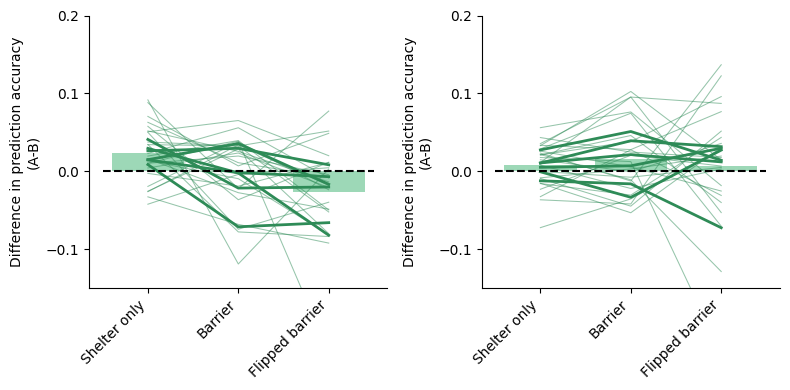

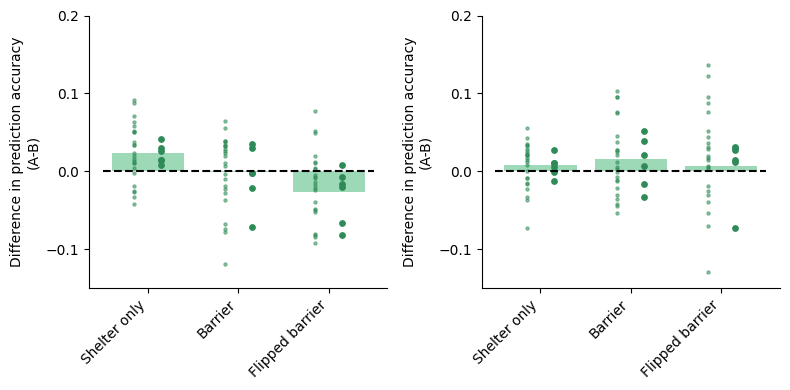

In [49]:
"""Is preflip prediction accuracy increasing? Is postflip decreasing?"""
fig, axs = plt.subplots(1,2, figsize = (8,4))
angle = ['h_preflipbar_a','h_postflipbar_a']
cond = ['Shelter only','Barrier','Flipped barrier']
pre_aligned = []
post_aligned = []
name = []
for c_idx, c in enumerate(conditions):
    if len(pre_aligned) == 0:
        pre_aligned = pa[angle[0]][:,c_idx,1] - pa[angle[0]][:,c_idx,0]
        post_aligned = pa[angle[1]][:,c_idx,1] - pa[angle[1]][:,c_idx,0]
    else:
        pre_aligned = np.vstack((pre_aligned, pa[angle[0]][:,c_idx,1] - pa[angle[0]][:,c_idx,0]))
        post_aligned = np.vstack((post_aligned,pa[angle[1]][:,c_idx,1] - pa[angle[1]][:,c_idx,0]))
    name.append(str(cond[c_idx]))

if np.shape(pre_aligned)[1] == 26:
    pre_aligned = np.delete(pre_aligned,15,1)
    post_aligned = np.delete(post_aligned,15,1)
    not_all_names = all_names[:15] + all_names[16:]
else:
    not_all_names = all_names
    
mouse_ID = [x[:6] for x in not_all_names]
unique_mouse = [x for i, x in enumerate(mouse_ID) if x not in mouse_ID[:i]]
mean_pre_aligned = np.zeros((len(unique_mouse),np.shape(pre_aligned)[0]))
mean_post_aligned = np.zeros((len(unique_mouse),np.shape(post_aligned)[0]))
for m_idx, m in enumerate(unique_mouse):
    this_mouse = [i for i,x in enumerate(mouse_ID) if x == m]
    mean_pre_aligned[m_idx,:] = np.mean(pre_aligned[:,this_mouse], axis=1)
    mean_post_aligned[m_idx,:] = np.mean(post_aligned[:,this_mouse], axis=1)

# plot the pred acc preflip
axs[0].bar(name,np.nanmean(pre_aligned,axis=1),color = 'mediumseagreen',alpha = .5)
axs[0].plot(name,pre_aligned,color = 'seagreen',alpha = .5, linewidth = .75)
axs[0].plot(name,mean_pre_aligned.T, linewidth = 2, color = 'seagreen')
axs[0].plot([-.5,np.shape(pre_aligned)[0]-.5],[0,0],'--k')
axs[0].set_xticks(np.arange(np.shape(pre_aligned)[0]))
axs[0].set_xticklabels(name,rotation = 45, ha="right")
axs[0].set_ylabel('Difference in prediction accuracy\n(A-B)')

# plot the pred acc preflip
axs[1].bar(name,np.nanmean(post_aligned,axis=1),color = 'mediumseagreen',alpha = .5)
axs[1].plot(name,post_aligned,color = 'seagreen',alpha = .5, linewidth = .75)
axs[1].plot(name,mean_post_aligned.T, linewidth = 2, color = 'seagreen')
axs[1].plot([-.5,np.shape(post_aligned)[0]-.5],[0,0],'--k')
axs[1].set_xticks(np.arange(np.shape(post_aligned)[0]))
axs[1].set_ylabel('Difference in prediction accuracy\n(B-A)')

for i in [0,1]:
    axs[i].set_xticklabels(name,rotation = 45, ha="right")
    axs[i].set_yticks([-.1,0,.1,.2])
    axs[i].set_ylim([-.15,.2])
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(save_path+'/'+str('pa_change_first_second_half_all_avg.png'))

"""Is preflip prediction accuracy increasing? Is postflip decreasing?"""
fig, axs = plt.subplots(1,2, figsize = (8,4))

# plot the pred acc preflip
axs[0].bar(name,np.nanmean(pre_aligned,axis=1),color = 'mediumseagreen',alpha = .5)
for i in [0,1,2]:
    axs[0].scatter((np.ones(len(pre_aligned[i,:]))*i)-.15,pre_aligned[i,:],s = 5,c = 'seagreen', alpha = .5)
    axs[0].scatter((np.ones(len(mean_pre_aligned[:,i]))*i)+.15,mean_pre_aligned[:,i].T,s = 15,c = 'seagreen')
axs[0].plot([-.5,np.shape(pre_aligned)[0]-.5],[0,0],'--k')
axs[0].set_xticks(np.arange(np.shape(pre_aligned)[0]))
axs[0].set_xticklabels(name,rotation = 45, ha="right")
axs[0].set_ylabel('Difference in prediction accuracy\n(second half- first half)')

# plot the pred acc preflip
axs[1].bar(name,np.nanmean(post_aligned,axis=1),color = 'mediumseagreen',alpha = .5)
for i in [0,1,2]:
    axs[1].scatter((np.ones(len(post_aligned[i,:]))*i)-.15,post_aligned[i,:],s = 5,c = 'seagreen', alpha = .5)
    axs[1].scatter((np.ones(len(mean_post_aligned[:,i]))*i)+.15,mean_post_aligned[:,i].T,s = 15,c = 'seagreen')
axs[1].plot([-.5,np.shape(post_aligned)[0]-.5],[0,0],'--k')
axs[1].set_xticks(np.arange(np.shape(post_aligned)[0]))
axs[1].set_ylabel('Difference in prediction accuracy\n(second half- first half)')

for i in [0,1]:
    axs[i].set_xticklabels(cond,rotation = 45, ha="right")
    axs[i].set_yticks([-.1,0,.1,.2])
    axs[i].set_ylim([-.15,.2])
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(save_path+'/'+str('scatter_pa_change_first_second_half_all_avg.png'))



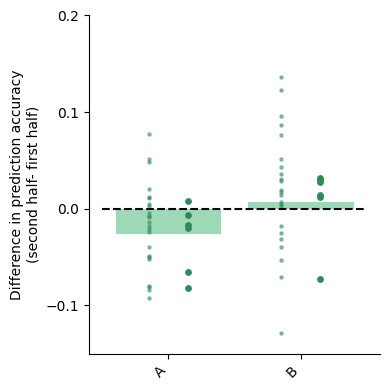

In [144]:
"""Flipped barrier: Is preflip prediction accuracy decreasing? Is postflip increasing?"""
fig, axs = plt.subplots(1,1, figsize = (4,4))

# plot the pred acc preflip
axs.bar(0,np.nanmean(pre_aligned[2,:]),color = 'mediumseagreen',alpha = .5)
axs.scatter((np.ones(len(pre_aligned[2,:]))*0)-.15,pre_aligned[2,:],s = 5,c = 'seagreen', alpha = .5)
axs.scatter((np.ones(len(mean_pre_aligned[:,2]))*0)+.15,mean_pre_aligned[:,2].T,s = 15,c = 'seagreen')

axs.bar(1,np.nanmean(post_aligned[2,:]),color = 'mediumseagreen',alpha = .5)
axs.scatter((np.ones(len(post_aligned[2,:])))-.15,post_aligned[2,:],s = 5,c = 'seagreen', alpha = .5)
axs.scatter((np.ones(len(mean_post_aligned[:,2])))+.15,mean_post_aligned[:,2].T,s = 15,c = 'seagreen')

axs.plot([-.5,1.5],[0,0],'--k')
axs.set_xticks([0,1])
axs.set_xticklabels(['A','B'],rotation = 45, ha="right")
axs.set_ylabel('Difference in prediction accuracy\n(second half- first half)')

axs.set_yticks([-.1,0,.1,.2])
axs.set_ylim([-.15,.2])
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig(save_path+'/'+str('flipped_bar_scatter_pa_change_first_second_half_all_avg.png'))

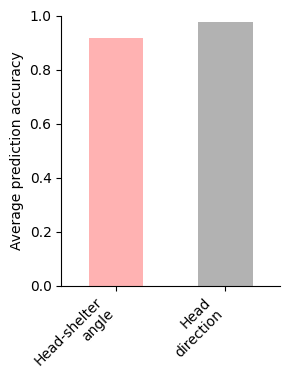

In [83]:
"""Bar plot for hdir and hsa average pa"""
from JR_test_scripts.tracking2features import load_prediction_accuracy
sesh = JAL4_3rdSept
session = get_experiment(sesh)
JAL4_coef = {}
for idx,c in enumerate(conditions):
    JAL4_coef[c] = load_prediction_accuracy(session, settings, c, 'experimental_conditions')

fig, axs = plt.subplots(1,1, figsize = (3,4))
axs.bar(0,JAL4_coef['shelter_only']['hsa'], facecolor = 'r', alpha = .3, width = .5)
axs.bar(1,JAL4_coef['shelter_only']['hdir'], facecolor = 'k', alpha = .3, width = .5)
axs.set_ylim([0,1])
axs.set_xlim([-.5,1.5])
axs.set_ylabel('Average prediction accuracy')
axs.set_xticks([0,1])
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
axs.set_xticklabels(['Head-shelter\nangle','Head\ndirection'],rotation = 45, ha = 'right')
plt.tight_layout()
plt.savefig(save_path+'/'+str('bar_plot_pred_acc_JAL4_3sep_hdir_hsa.png'))

In [65]:
JAL4_coef['shelter_only']['hdir']

np.float64(0.9776828314730635)